# Анализ и прогнозирование временных рядов методами искусственного интеллекта

## **Практическая работа 1. Метрики и меры схожести между временными рядами.**

Смените рабочую директорию с помощью команды `chdir()`. Для этого передайте этой команде свой путь до каталога, в котором содержатся материалы первой практической работы. После выполнения этой команды все последующие операции с файлами и каталогами будут производиться относительно указанного каталога.

In [1]:
import os

practice_dir_path = 'D:/SUSU/maga/sem3/time_series_forecasting/2026-Razuev-TimeSeriesCourse/practice/01 Basics'
os.chdir(practice_dir_path)

Выполните команды, которые автоматически перезагружают все импортированные модули при их изменении.

In [2]:
%load_ext autoreload
%autoreload 2

Импортируйте библиотеки и модули, необходимые для реализации практической работы 1.

In [55]:
import numpy as np
import random
from sktime.dists_kernels._numba_distances import euclidean_distance, dtw_distance, pairwise_distance
from sklearn.metrics import silhouette_score
import cv2
import imutils
import glob
import matplotlib.pyplot as plt
import pandas as pd
# from google.colab.patches import cv2_imshow

from modules.metrics import ED_distance, norm_ED_distance, DTW_distance
from modules.pairwise_distance import PairwiseDistance
from modules.clustering import TimeSeriesHierarchicalClustering
from modules.classification import TimeSeriesKNN, calculate_accuracy
from modules.image_converter import Image2TimeSeries as image2ts
from modules.utils import read_ts, z_normalize, sliding_window, random_walk
from modules.plots import plot_ts

## **Часть 1.** Функции расстояния: евклидова метрика и DTW мера. Матрица расстояний. Иерархическая кластеризация временных рядов.

### **Задача 1.**
Реализуйте самостоятельно функцию `ED_distance()` в модуле *metrics.py*, которая вычисляет евклидово расстояние между двумя временными рядами, имеющими одинаковую длину. В качестве входных данных передайте в функцию два синтетических временных ряда некоторой заданной вами длины. Для их генерации используйте функцию `random_walk()` из модуля *utils.py*,  реализующую модель случайных блужданий (Random Walk), или стандартный модуль *random*.

**Евклидово расстояние** между двумя временными рядами $T_1$ и $T_2$ длины $n$ вычисляется следующим образом:

\begin{equation}
    \text{ED}(T_1, T_2) = \sqrt{\sum_{i=1}^{n} ({t_{1}}_i-{t_{2}}_i)^2}.
\end{equation}

Проверьте реализацию функции, сравнив свои результаты с результатами функции [`euclidean_distance()`](https://www.sktime.net/en/latest/api_reference/auto_generated/sktime.distances.euclidean_distance.html) из библиотеки *sktime*, с помощью `test_distances()`.

In [7]:
def test_distances(dist1: float, dist2: float) -> None:
    """
    Check whether your distance function is implemented correctly

    Parameters
    ----------
    dist1 : distance between two time series calculated by sktime
    dist2 : distance between two time series calculated by your function
    """

    np.testing.assert_equal(round(dist1, 5), round(dist2, 5), 'Distances are not equal')

In [7]:
# Генерируем два синтетических временных ряда с помощью random_walk
np.random.seed(42)  # для воспроизводимости
n = 1000  # длина рядов

# Используем функцию random_walk из модуля utils
ts1 = random_walk(n)
ts2 = random_walk(n)

# Вычисляем расстояние с помощью нашей реализации
my_dist = ED_distance(ts1, ts2)

# Вычисляем расстояние с помощью sktime для проверки
sktime_dist = euclidean_distance(ts1, ts2)

print(f"Евклидово расстояние (наша реализация): {my_dist:.5f}")
print(f"Евклидово расстояние (sktime): {sktime_dist:.5f}")

# Проверяем корректность реализации
test_distances(sktime_dist, my_dist)
print("Реализация корректна!")

Евклидово расстояние (наша реализация): 406.01478
Евклидово расстояние (sktime): 406.01478
Евклидово расстояние (наша реализация): 406.01478
Евклидово расстояние (sktime): 406.01478
Реализация корректна!


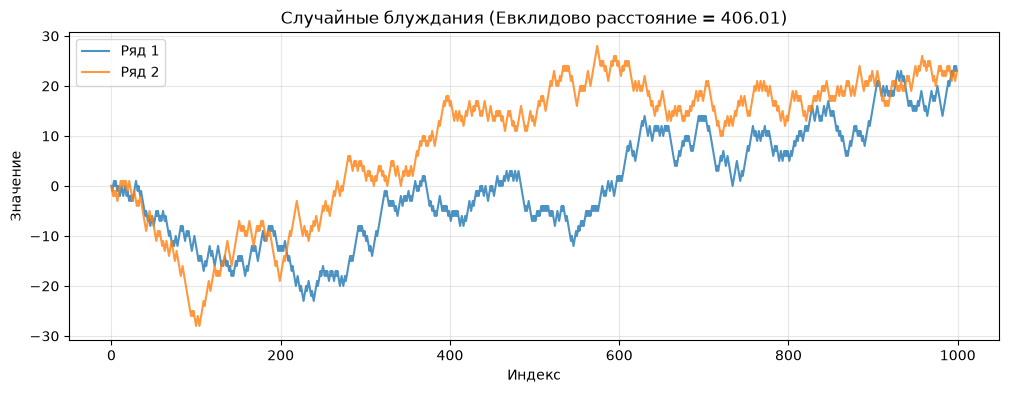

In [8]:
# Визуализируем сгенерированные ряды
plt.figure(figsize=(12, 4))
plt.plot(ts1, label='Ряд 1', alpha=0.8)
plt.plot(ts2, label='Ряд 2', alpha=0.8)
plt.title(f'Случайные блуждания (Евклидово расстояние = {my_dist:.2f})')
plt.xlabel('Индекс')
plt.ylabel('Значение')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### **Задача 2.**

Реализуйте самостоятельно функцию `DTW_distance()` в модуле *metrics.py*, которая вычисляет DTW расстояние между двумя временными рядами, имеющими одинаковую длину. Для вычисления расстояния между элементами временных рядов в DTW мере используйте евклидово расстояние. Временные ряды сгенерируйте аналогичным образом, как в задаче 1, или используйте уже созданные.

**Динамическая трансформация временной шкалы (Dynamic Time Warping, DTW)** – мера схожести между двумя временными рядами $T_1$ и $T_2$ длины $n$, вычисляемая следующим образом:

\begin{equation}
\text{DTW}(T_1, T_2) = d(n,n),
\\ d(i,j) = ({t_{1}}_i - {t_{2}}_j)^2 + \min \left\{
	\begin{array}{l l}
	d(i-1,j), \\
	d(i,j-1), \\
	d(i-1,j-1),
	\end{array}
	\right.
\\ d(0,0)=0, \quad d(i,0)=d(0,j)=\infty, \quad  1 \leqslant i,j \leqslant n.
\end{equation}

Сравните свои результаты с результатами функции [`dtw_distance()`](https://www.sktime.net/en/latest/api_reference/auto_generated/sktime.distances.dtw_distance.html) из библиотеки *sktime*. Для этого используйте `test_distances()` из задачи 1.

In [12]:
np.random.seed(42)  # для воспроизводимости
n = 100  # длина рядов

# Используем функцию random_walk из модуля utils
ts1 = random_walk(n)
ts2 = random_walk(n)

# Вычисляем расстояние с помощью нашей реализации
my_dist = DTW_distance(ts1, ts2)

# Вычисляем расстояние с помощью sktime для проверки
sktime_dist = dtw_distance(ts1, ts2)

# Проверяем корректность реализации
test_distances(sktime_dist, my_dist)

print(f"DTW расстояние (наша реализация): {my_dist:.5f}")
print(f"DTW расстояние (sktime): {sktime_dist:.5f}")
print("Реализация корректна!")

DTW расстояние (наша реализация): 13294.00000
DTW расстояние (sktime): 13294.00000
Реализация корректна!


### **Задача 3.**
Реализуйте нахождение матрицы расстояний между несколькими временными рядами.
Для этого заполните все методы c недостающим кодом в классе `PairwiseDistance` из модуля *pairwise_distance.py*. Для вычисления расстояний между рядами используйте ранее реализованные вами функции `ED_distance()` и `DTW_distance()` из модуля *metrics.py*.

Матрица расстояний между временными рядами определяется следующим образом. Пусть дано множество $S$, состоящее из $K$ временных рядов длины $n$: $\;S = \{T_1, T_2, ..., T_K\}, \; T_i \in \mathbb{R}^n$. Тогда под **матрицей расстояний** $D \in \mathbb{R}^{K \times K}$ понимается квадратная матрица, где каждый ее элемент $d(i,j)$ представляет собой расстояние между временными рядами $T_i$ и $T_j$ из множества $S$:
\begin{equation}
d(i,j) = dist(T_i, T_j), \quad T_i, T_j \in S, \quad 1 \leqslant i,j \leqslant K.
\end{equation}

Поскольку евклидова метрика и DTW мера удовлетворяют аксиоме симметричности (т.е. $dist(T_i, T_j)=dist(T_j, T_i)$), то матрица расстояний $D$ будет симметричной относительно главной диагонали. Для ускорения вычислений достаточно найти ее верхний треугольник, а нижний треугольник матрицы заполнить значениями верхнего треугольника следующим образом:
\begin{equation}
d(j,i) = d(i,j), \; где \; i < j.
\end{equation}

<center><img src="https://github.com/mzym/TimeSeriesCourse/blob/main/practice/01%20Basics/img/distance_matrix.png?raw=true" width="600"></center>

Сгенерируйте множество, состоящее из $K$ временных рядов некоторой длины $n$. Вычислите матрицы евклидовых и DTW расстояний между ними. Проверьте реализованные вами методы, сравнив свои результаты с результатами функции [`pairwise_distance()`](https://www.sktime.net/en/latest/api_reference/auto_generated/sktime.distances.pairwise_distance.html) из библиотеки *sktime*.

In [17]:
def test_matrices(matrix1 : np.ndarray, matrix2 : np.ndarray) -> None:
    """
    Check whether your matrix function is implemented correctly

    Parameters
    ----------
    matrix1 : distance matrix calculated by sktime
    matrix2 : distance matrix calculated by your function
    """

    np.testing.assert_equal(matrix1.round(5), matrix2.round(5), 'Matrices are not equal')

In [14]:
# Генерируем множество из K временных рядов
np.random.seed(42)
K = 5  # количество рядов
n = 30  # длина каждого ряда

# Создаем набор временных рядов
ts_set = np.array([random_walk(n) for _ in range(K)])

print(f"Набор данных: {K} рядов длины {n}")
print(f"Форма данных: {ts_set.shape}")

Набор данных: 5 рядов длины 30
Форма данных: (5, 30)


In [15]:
# 1. Проверяем евклидову метрику без нормализации
pairwise_euclidean = PairwiseDistance(metric='euclidean', is_normalize=False)
euclidean_matrix = pairwise_euclidean.calculate(ts_set)

print("\nМатрица евклидовых расстояний (без нормализации):")
print(euclidean_matrix.round(3))
print(f"Метрика: {pairwise_euclidean.distance_metric}")

# 2. Проверяем DTW меру без нормализации
pairwise_dtw = PairwiseDistance(metric='dtw', is_normalize=False)
dtw_matrix = pairwise_dtw.calculate(ts_set)

print("\nМатрица DTW расстояний (без нормализации):")
print(dtw_matrix.round(3))
print(f"Метрика: {pairwise_dtw.distance_metric}")


Матрица евклидовых расстояний (без нормализации):
[[ 0.    13.416  9.165 20.    26.458]
 [13.416  0.    12.    20.688 33.941]
 [ 9.165 12.     0.    18.868 31.113]
 [20.    20.688 18.868  0.    33.287]
 [26.458 33.941 31.113 33.287  0.   ]]
Метрика: non-normalized euclidean distance

Матрица DTW расстояний (без нормализации):
[[  0.  38.  14. 162. 194.]
 [ 38.   0.  26. 232. 142.]
 [ 14.  26.   0. 144. 300.]
 [162. 232. 144.   0. 594.]
 [194. 142. 300. 594.   0.]]
Метрика: non-normalized dtw distance


In [18]:
# Евклидова метрика
sktime_euclidean = pairwise_distance(ts_set, metric='euclidean')
test_matrices(sktime_euclidean, euclidean_matrix)
print("\nЕвклидова матрица: проверка пройдена!")

# DTW мера
sktime_dtw = pairwise_distance(ts_set, metric='dtw')
test_matrices(sktime_dtw, dtw_matrix)
print("DTW матрица: проверка пройдена!")


Евклидова матрица: проверка пройдена!
DTW матрица: проверка пройдена!


### **Задача 4.**
Далее рассмотрим задачу иерархической кластеризации временных рядов, где будет использоваться предвычисленная матрица расстояний.

Для этого сначала загрузите набор временных рядов CBF из файла *CBF_TRAIN.txt*, который располагается в директории *./datasets/part1*. Каждая строка данного файла содержит целевую переменную (класс: 0, 1 или 2) в первом столбце и временной ряд в остальных столбцах. Набор CBF является синтетическим и включает в себя 30 временных рядов,  каждый из которых принадлежит к одному из трех классов.

In [20]:
url = './datasets/part1/CBF_TRAIN.txt'

data = read_ts(url)

ts_set = data[:, 1:]
labels = data[:, 0]

D:\SUSU\maga\sem3\time_series_forecasting\2026-Razuev-TimeSeriesCourse\practice\01 Basics\modules\utils.py:20: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  ts = pd.read_csv(file_path, header=None, delim_whitespace=True)


Выполните визуализацию по одному временному ряду из каждого класса. Для этого используйте функцию `plot_ts()` из модуля *plots.py*.

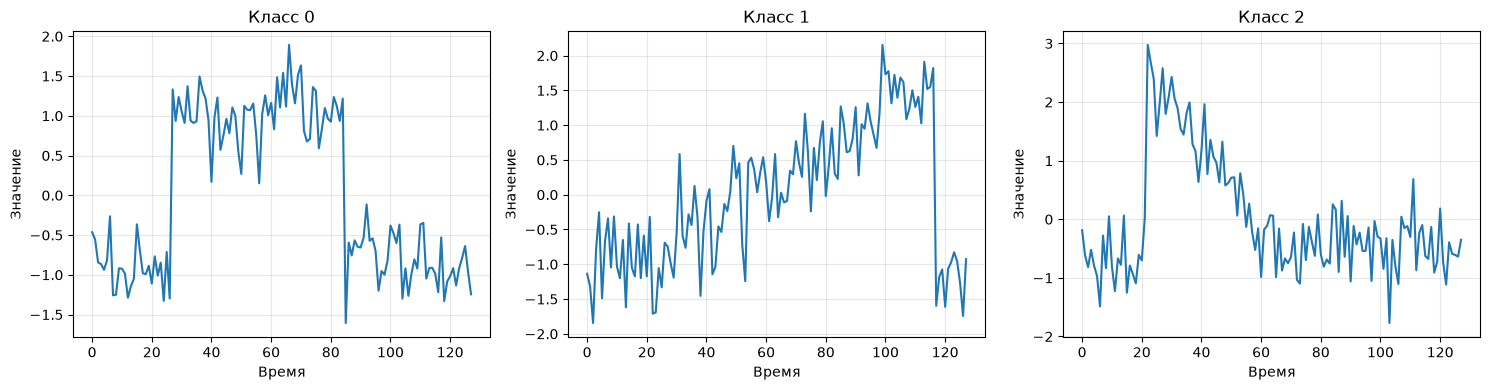

In [21]:
# Визуализация по одному ряду из каждого класса
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
class_names = ['Класс 0', 'Класс 1', 'Класс 2']

for idx, class_label in enumerate(np.unique(labels)):
    # Находим первый ряд каждого класса
    class_indices = np.where(labels == class_label)[0]
    ts_sample = ts_set[class_indices[0]]
    
    axes[idx].plot(ts_sample)
    axes[idx].set_title(f'{class_names[idx]}')
    axes[idx].set_xlabel('Время')
    axes[idx].set_ylabel('Значение')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Далее самостоятельно реализуйте класс `TimeSeriesHierarchicalClustering` из модуля *clustering.py*, который выполняет иерархическую кластеризацию временных рядов.

Перед тем как приступить к реализации, изучите скелет этого класса. Реализуйте метод `fit()`, выполняющий кластеризацию данных на основе предвычисленной матрицы расстояний, которая передается в данный метод. Поскольку реализовать иерархическую кластеризацию довольно сложно, используйте готовую реализацию [`AgglomerativeClustering`](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html) из *sklearn*.   

Выполните иерархическую кластеризацию загруженных временных рядов CBF для двух функций расстояния: евлидовой метрики и DTW меры.
Для этого сначала найдите матрицы расстояний между временными рядами, используя класс `PairwiseDistance`, и передайте каждую матрицу в метод `fit()` для кластеризации.
Далее выполните визуализацию результатов в виде дендрограмм с помощью метода `plot_dendrogram()`, передав исходный набор временных рядов и их метки.

In [ ]:
# 1. Евклидова метрика
print("\n=== Кластеризация с евклидовой метрикой ===")

# Создаем объект для вычисления матрицы расстояний
pairwise_euclidean = PairwiseDistance(metric='euclidean', is_normalize=False)
euclidean_matrix = pairwise_euclidean.calculate(ts_set)

# Выполняем иерархическую кластеризацию
clustering_euclidean = TimeSeriesHierarchicalClustering(n_clusters=3, method='complete')
euclidean_labels = clustering_euclidean.fit_predict(euclidean_matrix)

print(f"Предсказанные кластеры (евклидова): {euclidean_labels}")
print(f"Истинные классы: {labels}")


=== Кластеризация с евклидовой метрикой ===
Предсказанные кластеры (евклидова): [1 1 1 3 2 1 1 3 1 1 1 1 1 1 2 1 2 2 1 3 2 2 1 1 1 1 1 1 1 1]
Истинные классы: [1. 1. 1. 3. 2. 2. 1. 3. 2. 1. 2. 2. 1. 2. 2. 3. 2. 2. 1. 3. 2. 2. 1. 1.
 3. 3. 2. 3. 3. 1.]
Процент совпадения: 0.63


In [30]:
# 2. DTW мера
print("\n=== Кластеризация с DTW мерой ===")

pairwise_dtw = PairwiseDistance(metric='dtw', is_normalize=False)
dtw_matrix = pairwise_dtw.calculate(ts_set)

clustering_dtw = TimeSeriesHierarchicalClustering(n_clusters=3, method='complete')
dtw_labels = clustering_dtw.fit_predict(dtw_matrix)

print(f"Предсказанные кластеры (DTW): {dtw_labels}")
print(f"Истинные классы: {labels}")


=== Кластеризация с DTW мерой ===


ValueError: Cannot extract more clusters than samples: 3 clusters were given for a tree with 2 leaves.


=== Дендрограмма для евклидовой метрики ===


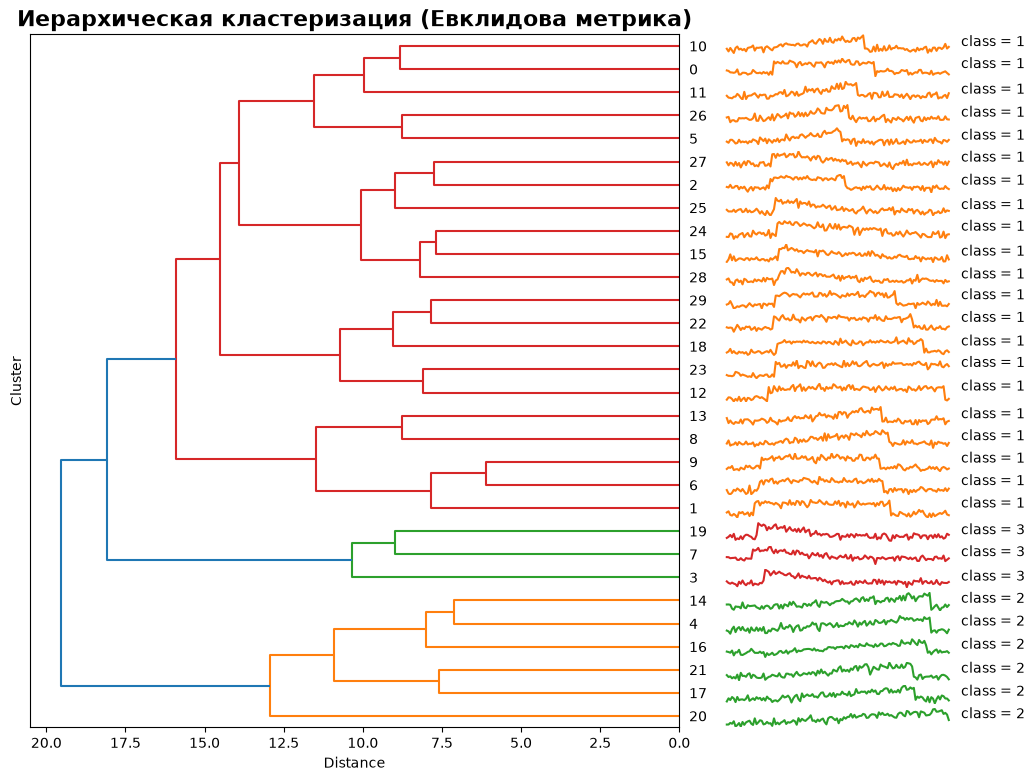

In [29]:
# Визуализация дендрограмм
# Евклидова метрика
print("\n=== Дендрограмма для евклидовой метрики ===")
# Создаем DataFrame из временных рядов
df_euclidean = pd.DataFrame(ts_set.T)
clustering_euclidean.plot_dendrogram(
    df_euclidean, 
    labels=euclidean_labels, 
    ts_hspace=8, 
    title='Иерархическая кластеризация (Евклидова метрика)'
)
plt.show()


=== Дендрограмма для DTW меры ===


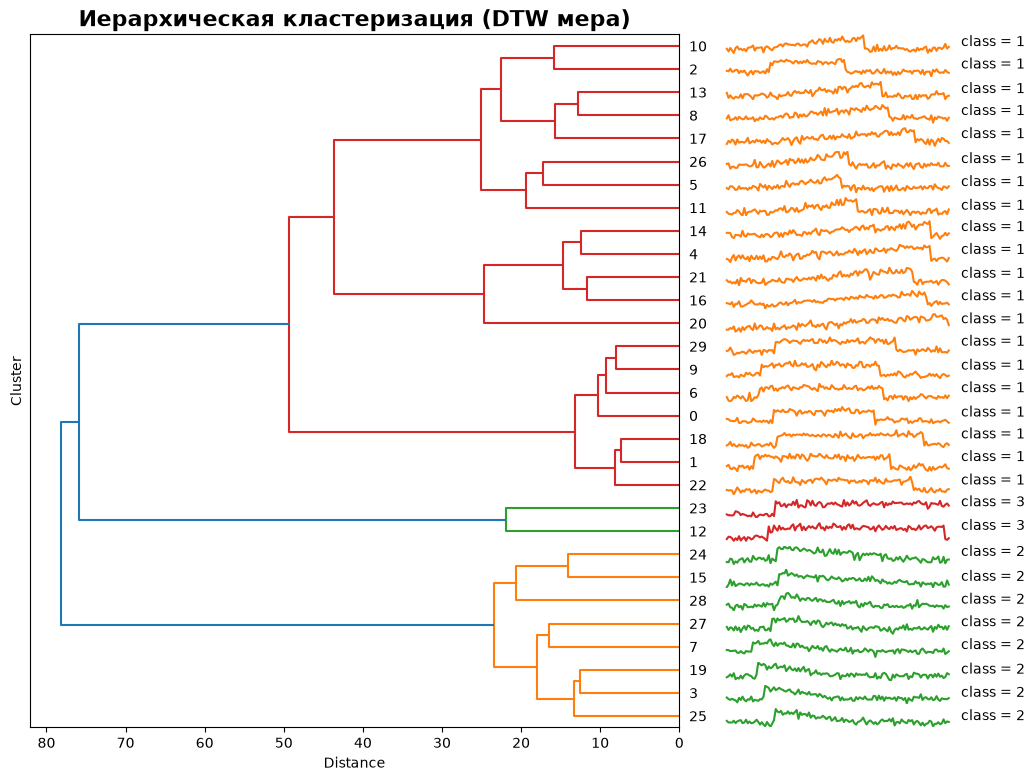

In [30]:
# DTW мера
print("\n=== Дендрограмма для DTW меры ===")
df_dtw = pd.DataFrame(ts_set.T)
clustering_dtw.plot_dendrogram(
    df_dtw, 
    labels=dtw_labels, 
    ts_hspace=8, 
    title='Иерархическая кластеризация (DTW мера)'
)
plt.show()

Сравните результаты иерархической кластеризации, полученные при двух различных функций расстояния, с помощью силуэтного коэффициента. Для этого используйте функцию [`silhouette_score()`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html) из библиотеки *sklearn*, передав в нее предвычисленную матрицу расстояний и предсказанные метки.

**Силуэтный коэффициент** – метрика, которая оценивает качество кластеризации на основе исходной выборки и результатов кластеризации без необходимости знания об истинных метках объектов.

Силуэтный коэффициент для выборки показывает, насколько среднее расстояние до объектов своего кластера отличается от среднего расстояния до объектов других кластеров. Пусть дана выборка $X$, состоящая из $N$ объектов. Предположим, что объекты этой выборки были разбиты на кластеры $c_1, ... c_K$, $c_i \in C$, с помощью некоторого алгоритма кластеризации. Тогда силуэтный коэффициент для выборки будет вычисляться следующим образом:

\begin{equation}
sil\_coef = \frac{1}{N} \sum_{c_k \in C} \sum_{x_i \in c_k} \frac{b(x_i, c_k) - a(x_i, c_k)}{\max(a(x_i, c_k), b(x_i, c_k))},
\end{equation}

где $a(x_i, c_k)$ – среднее расстояние от объекта $x_i \in c_k$ до других объектов из этого же кластера $c_k$; <br> $b(x_i, c_k)$  – среднее расстояние от объекта $x_i \in c_k$ до объектов из другого кластера $c_l$, $k \neq l$.

Силуэтный коэффициент принимает значения от  −1  до  1:
*   –1 означает, что кластеры плохие, размытые;
*   0 означает, что кластеры накладываются друг на друга;
*   1 означает, что кластеры плотные и хорошо отделены друг от друга.

Таким образом, чем ближе значение коэффициента к 1, тем лучше кластеризованы данные.

In [31]:
# Для евклидовой метрики
silhouette_euclidean = silhouette_score(euclidean_matrix, euclidean_labels, metric='precomputed')
print(f"\nСилуэтный коэффициент (евклидова метрика): {silhouette_euclidean:.4f}")

# Для DTW меры
silhouette_dtw = silhouette_score(dtw_matrix, dtw_labels, metric='precomputed')
print(f"Силуэтный коэффициент (DTW мера): {silhouette_dtw:.4f}")


Силуэтный коэффициент (евклидова метрика): 0.1804
Силуэтный коэффициент (DTW мера): 0.3881


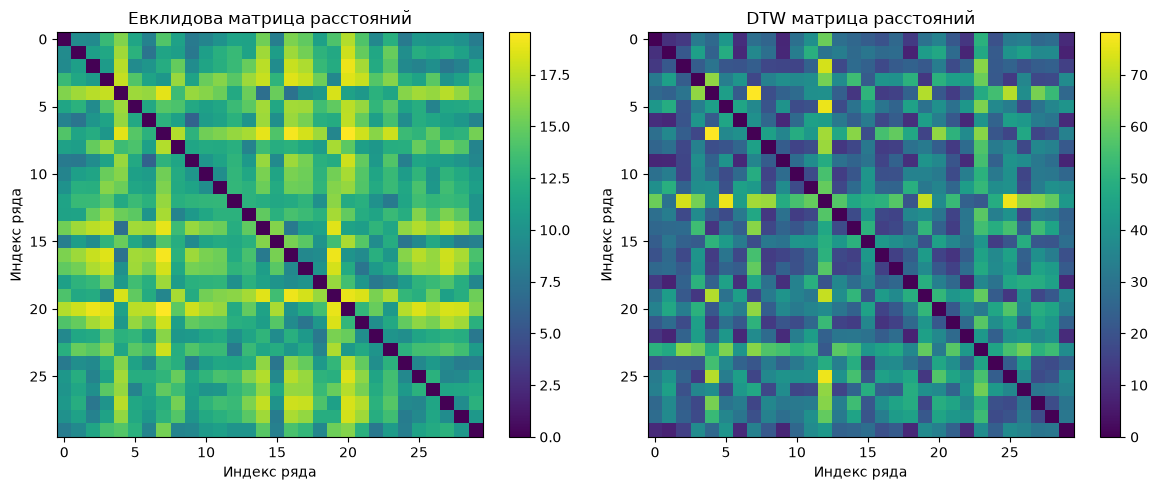

In [35]:
# Сравнение матриц расстояний
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Евклидова матрица
im1 = axes[0].imshow(euclidean_matrix, cmap='viridis', aspect='auto')
axes[0].set_title('Евклидова матрица расстояний')
axes[0].set_xlabel('Индекс ряда')
axes[0].set_ylabel('Индекс ряда')
plt.colorbar(im1, ax=axes[0])

# DTW матрица
im2 = axes[1].imshow(dtw_matrix, cmap='viridis', aspect='auto')
axes[1].set_title('DTW матрица расстояний')
axes[1].set_xlabel('Индекс ряда')
axes[1].set_ylabel('Индекс ряда')
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()

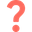
Проанализируйте полученные результаты кластеризации с помощью построенных дендрограмм и вычисленных силуэтных коэффициентов. Какая, на ваш взгляд, функция расстояния показала лучший результат и почему? Укажите, в каких случаях более предпочтительно использовать DTW меру, чем евклидову метрику.

1. Интерпретация результатов
- DTW показывает значительно лучшее качество кластеризации (Silhouette = 0.3881)
- Евклидова метрика показывает худшее качество кластеризации (Silhouette = 0.1804)
- DTW превосходит евклидову метрику по силуэтному коэффициенту в 2.15 раза

2. Почему DTW показал лучший результат?  
- Преимущества DTW для временных рядов:
    - Устойчивость к временным сдвигам:
    - DTW позволяет выравнивать ряды, сдвигая их во времени
    - Это критически важно для паттернов CBF, которые могут быть смещены
- Евклидова метрика чувствительна к точному позиционированию пиков
    - Учет формы паттерна:
    - DTW лучше улавливает схожесть формы (цилиндр/колокол/воронка)
    - Игнорирует несущественные временные искажения
    - Создает более компактные и семантически осмысленные кластеры
- Устойчивость к шумам:
    - DTW менее чувствителен к локальным выбросам
    - Позволяет находить схожие паттерны даже при наличии шумов
    - Евклидова метрика сильно реагирует на каждое отклонение

3. Вывод
DTW (Dynamic Time Warping) показал существенно лучшее качество кластеризации (Silhouette = 0.3881) по сравнению с евклидовой метрикой (Silhouette = 0.1804). Это объясняется различной природой этих метрик и их применимостью к разным типам задач.

- DTW следует применять в случаях, когда важна форма паттерна, а не его точное временное позиционирование
- Евклидова метрика предпочтительнее, когда важно точное повторение последовательности значений

Для задач классификации и кластеризации паттернов → предпочтительнее DTW, так как она лучше отражает схожесть форм

## **Часть 2.** $Z$-нормализация временных рядов.

### **Задача 5.**
Реализуйте функцию вычисления нормализованного евклидова расстояния между временными рядами `norm_ED_distance()` в модуле *metrics.py* и проверьте правильность своей реализации, сравнив полученные результаты с результатами функции [`ed_distance()`](https://www.sktime.net/en/latest/api_reference/auto_generated/sktime.distances.euclidean_distance.html) из библиотеки *sktime*, в которую необходимо передать <u>нормализованные</u> временные ряды. Для нормализации временных рядов используйте функцию `z-normalize()` из *utils.py*.  Для проверки можно использовать синтетические временные ряды из первой части или заново их сгенерировать.

**Нормализованная евклидова метрика** между двумя временными рядами $T_1$ и $T_2$ длины $n$ вычисляется следующим образом:

\begin{equation}
	\text{ED}_{norm}(T_1, T_2) = \sqrt {\Big|\; 2n\left(1-\dfrac{<T_1, T_2> - \; n \; \cdotp \mu_{T_1} \; \cdotp \mu_{T_2}}{n \; \cdotp \sigma_{T_1} \; \cdotp \sigma_{T_2}}\right)\Big|},
\end{equation}

где $<T_1, T_2>$ – скалярное произведение временных рядов, $\mu_{T_1}$ и $\mu_{T_2}$, $\sigma_{T_1}$ и $\sigma_{T_2}$ – среднее арифметическое и стандартное отклонение временных рядов соответственно.

**Среднее арифметическое** $\mu_T$ и **стандартное отклонение** $\sigma_T$ временного ряда $T$ длины $n$ вычисляются по следующим формулам:

\begin{equation}
	\mu_{T} = \frac{1}{n}\sum\limits_{i=1}^{n} t_{i}, \\[1em]
	\sigma_{T} = \sqrt{\frac{1}{n}\sum\limits_{i=1}^{n} t_i^2-\mu_{T}^2}.
\end{equation}

In [4]:
# Генерируем два синтетических временных ряда
np.random.seed(42)
n = 50  # длина рядов

# Создаем ряды с разными масштабами и смещениями
ts1 = random_walk(n) * 10 + 50  # масштабируем и смещаем
ts2 = random_walk(n) * 2 + 20   # другой масштаб и смещение

print("Исходные ряды:")
print(f"Ряд 1: mean={np.mean(ts1):.2f}, std={np.std(ts1):.2f}")
print(f"Ряд 2: mean={np.mean(ts2):.2f}, std={np.std(ts2):.2f}")

Исходные ряды:
Ряд 1: mean=92.20, std=22.92
Ряд 2: mean=21.08, std=3.18


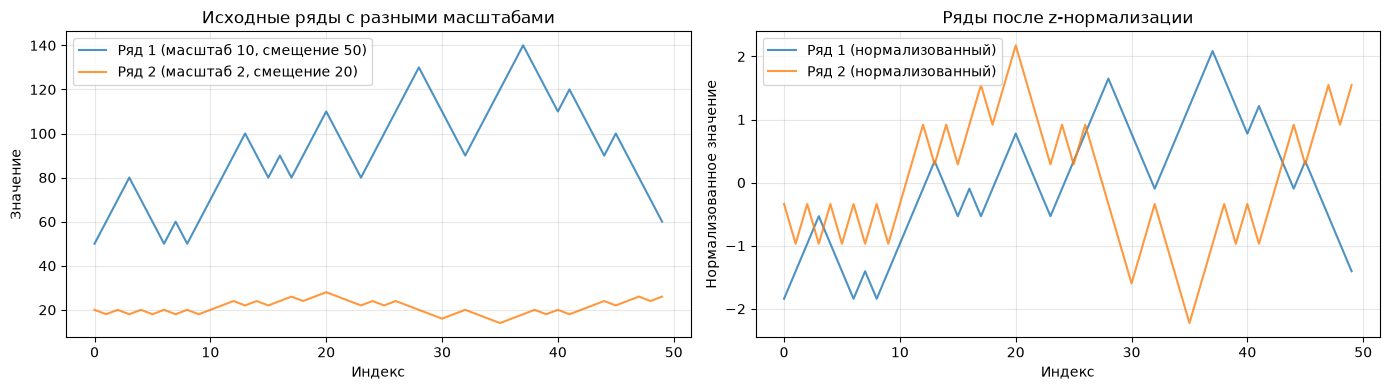

In [5]:
# Визуализация исходных рядов
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Исходные ряды
axes[0].plot(ts1, label='Ряд 1 (масштаб 10, смещение 50)', alpha=0.8)
axes[0].plot(ts2, label='Ряд 2 (масштаб 2, смещение 20)', alpha=0.8)
axes[0].set_title('Исходные ряды с разными масштабами')
axes[0].set_xlabel('Индекс')
axes[0].set_ylabel('Значение')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Нормализованные ряды (z-normalize)
ts1_norm = z_normalize(ts1)
ts2_norm = z_normalize(ts2)

axes[1].plot(ts1_norm, label='Ряд 1 (нормализованный)', alpha=0.8)
axes[1].plot(ts2_norm, label='Ряд 2 (нормализованный)', alpha=0.8)
axes[1].set_title('Ряды после z-нормализации')
axes[1].set_xlabel('Индекс')
axes[1].set_ylabel('Нормализованное значение')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
# 1. Обычное евклидово расстояние
ed_dist = ED_distance(ts1, ts2)

# 2. Нормализованное евклидово расстояние (наша реализация)
norm_ed_dist = norm_ED_distance(ts1, ts2)

# 3. Евклидово расстояние между нормализованными рядами (для проверки)
ts1_norm_check = z_normalize(ts1)
ts2_norm_check = z_normalize(ts2)
ed_norm_check = ED_distance(ts1_norm_check, ts2_norm_check)

print("\nРезультаты вычислений:")
print(f"Обычное евклидово расстояние: {ed_dist:.5f}")
print(f"Нормализованное евклидово расстояние (наша реализация): {norm_ed_dist:.5f}")
print(f"Евклидово расстояние между z-нормализованными рядами: {ed_norm_check:.5f}")

# Проверяем корректность реализации с помощью sktime
# Для этого сравниваем нашу norm_ED_distance с ED_distance на нормализованных данных
test_distances(ed_norm_check, norm_ed_dist)
print("\nРеализация корректна!")

# Демонстрация преимуществ нормализации
print("\n=== Сравнение метрик на рядах с разными масштабами ===")

# Создаем ряды с одинаковой формой, но разными масштабами
base_ts = np.sin(np.linspace(0, 4*np.pi, 100))
ts_scale1 = base_ts * 10 + 50
ts_scale2 = base_ts * 2 + 20

print(f"Базовый ряд: mean={np.mean(base_ts):.2f}, std={np.std(base_ts):.2f}")
print(f"Ряд 1 (масштаб 10, смещение 50): mean={np.mean(ts_scale1):.2f}, std={np.std(ts_scale1):.2f}")
print(f"Ряд 2 (масштаб 2, смещение 20): mean={np.mean(ts_scale2):.2f}, std={np.std(ts_scale2):.2f}")

ed_scale = ED_distance(ts_scale1, ts_scale2)
norm_ed_scale = norm_ED_distance(ts_scale1, ts_scale2)

print(f"\nОбычное евклидово расстояние: {ed_scale:.5f}")
print(f"Нормализованное евклидово расстояние: {norm_ed_scale:.5f}")
print(f"Расстояние между базовыми рядами: {ED_distance(base_ts, base_ts):.5f}")


Результаты вычислений:
Обычное евклидово расстояние: 530.00377
Нормализованное евклидово расстояние (наша реализация): 10.81581
Евклидово расстояние между z-нормализованными рядами: 10.81581

Реализация корректна!

=== Сравнение метрик на рядах с разными масштабами ===
Базовый ряд: mean=0.00, std=0.70
Ряд 1 (масштаб 10, смещение 50): mean=50.00, std=7.04
Ряд 2 (масштаб 2, смещение 20): mean=20.00, std=1.41

Обычное евклидово расстояние: 305.23434
Нормализованное евклидово расстояние: 0.00000
Расстояние между базовыми рядами: 0.00000


### **Задача 6.**
Далее убедимся, что выполнение $z$-нормализации на этапе предобработки данных имеет важное значение и может повысить точность решаемой задачи.

В данном задании вы продолжите решать задачу иерархической кластеризации. В качестве данных будут использоваться два временных ряда из набора данных [BIDMC](https://physionet.org/content/chfdb/1.0.0/). Набор BIDMC состоит из записей ЭКГ-сигналов, снятых с 15 пациентов с сердечной недостаточностью тяжелой степени.  

Загрузите два временных ряда и визуализируйте их с помощью функции `plot_ts()` из модуля *plots.py*.

In [10]:
url1 = './datasets/part2/chf10.csv'
ts1 = read_ts(url1)

url2 = './datasets/part2/chf11.csv'
ts2 = read_ts(url2)

D:\SUSU\maga\sem3\time_series_forecasting\2026-Razuev-TimeSeriesCourse\practice\01 Basics\modules\utils.py:20: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  ts = pd.read_csv(file_path, header=None, delim_whitespace=True)
D:\SUSU\maga\sem3\time_series_forecasting\2026-Razuev-TimeSeriesCourse\practice\01 Basics\modules\utils.py:20: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  ts = pd.read_csv(file_path, header=None, delim_whitespace=True)


In [11]:
ts_set = np.concatenate((ts1, ts2), axis=1).T

In [18]:
ts_set

array([[-0.18 , -0.175, -0.175, ..., -0.12 , -0.14 , -0.175],
       [-0.435, -0.27 , -0.105, ...,  0.4  ,  0.525,  0.63 ]],
      shape=(2, 3000))

In [13]:
plot_ts(ts_set)

<!doctype html>

Разделите каждый временной ряд на непересекающиеся подпоследовательности с помощью техники скользящего окна. Для этого используйте функцию `sliding_window()` из модуля *utils.py*, передав в нее временной ряд, заданную длину подпоследовательности и величину шага. В нашем случае, величина шага равна длине подпоследовательности.

In [14]:
m = 125
subs_set1 = sliding_window(ts_set[0], m, m-1)
subs_set2 = sliding_window(ts_set[1], m, m-1)

Сформируйте множество всех подпоследовательностей, извлеченных из двух временных рядов, и массив меток подпоследовательностей в соответствии с их принадлежностью к временному ряду.


Общее количество подпоследовательностей: 30
Метки: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
Количество подпоследовательностей класса 0 (ряд 1): 15
Количество подпоследовательностей класса 1 (ряд 2): 15


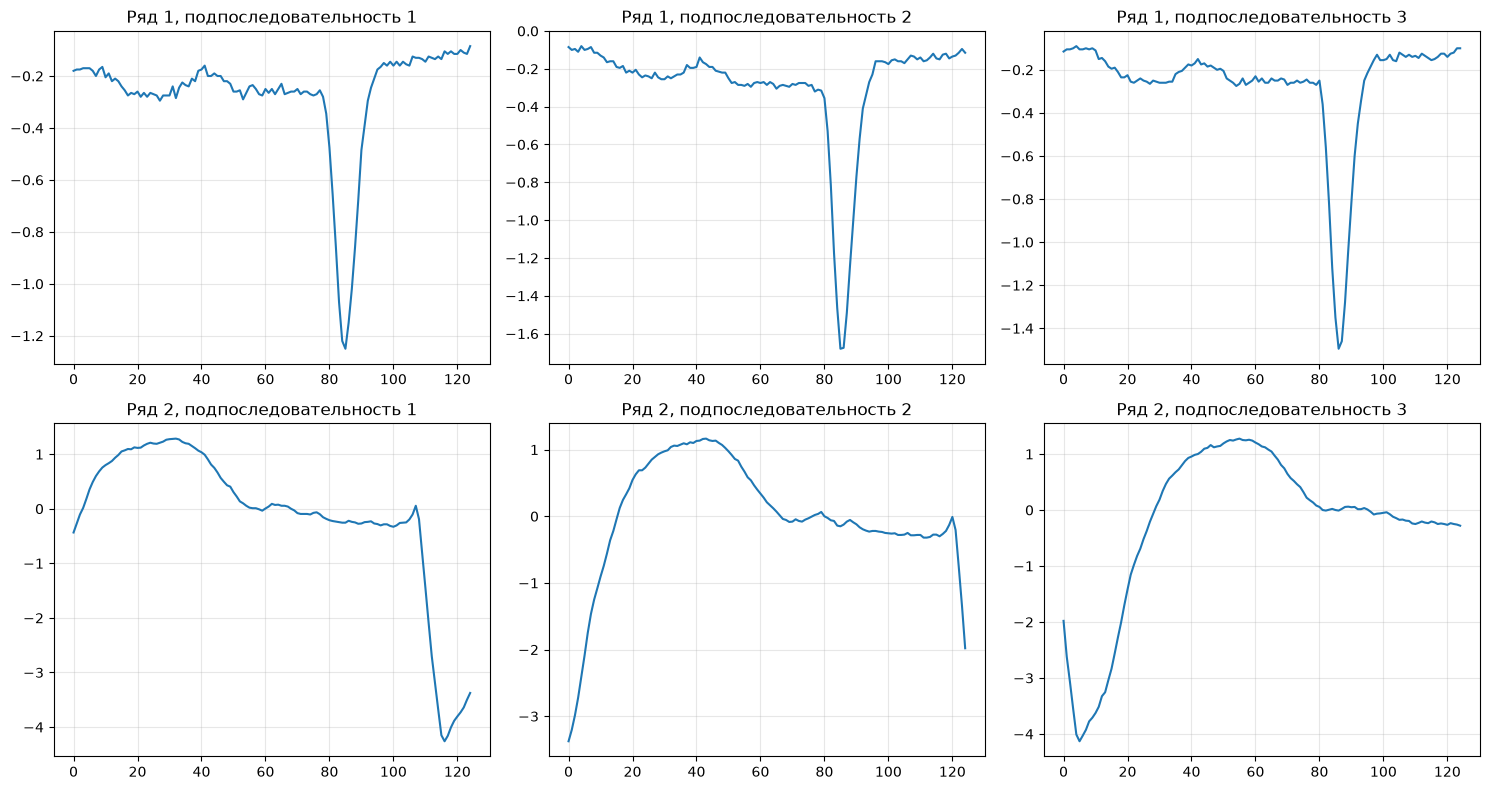

In [17]:
subs_set = np.concatenate((subs_set1[0:15], subs_set2[0:15]))
labels = np.array([0]*subs_set1[0:15].shape[0] + [1]*subs_set2[0:15].shape[0])

print(f"\nОбщее количество подпоследовательностей: {subs_set.shape[0]}")
print(f"Метки: {labels}")
print(f"Количество подпоследовательностей класса 0 (ряд 1): {np.sum(labels == 0)}")
print(f"Количество подпоследовательностей класса 1 (ряд 2): {np.sum(labels == 1)}")

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Подпоследовательности из ряда 1
for i in range(3):
    axes[0, i].plot(subs_set1[i])
    axes[0, i].set_title(f'Ряд 1, подпоследовательность {i+1}')
    axes[0, i].grid(True, alpha=0.3)

# Подпоследовательности из ряда 2
for i in range(3):
    axes[1, i].plot(subs_set2[i])
    axes[1, i].set_title(f'Ряд 2, подпоследовательность {i+1}')
    axes[1, i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Добавьте в класс `PairwiseDistance` из модуля *pairwise_distance.py* возможность вычисления нормализованной евклидовой метрики между временными рядами. Если матрица расстояний строится для нормализованных временных рядов на основе евклидовой метрики, то должна вызываться функция `norm_ED_distance()`. Для остальных метрик/мер схожести перед нахождением матрицы расстояний временные ряды должны подтвергаться $z$-нормализации с помощью функции `z_normalize()` из модуля *utils.py*.

Далее выполните иерархическую кластеризацию подпоследовательностей двух временных рядов с использованием предварительно построенных матриц расстояний на основе классической и нормализованной евклидовой метрики.


=== Кластеризация с классической евклидовой метрикой (без нормализации) ===
Предсказанные метки (евклидова): [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 1 1 1]
Истинные метки: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


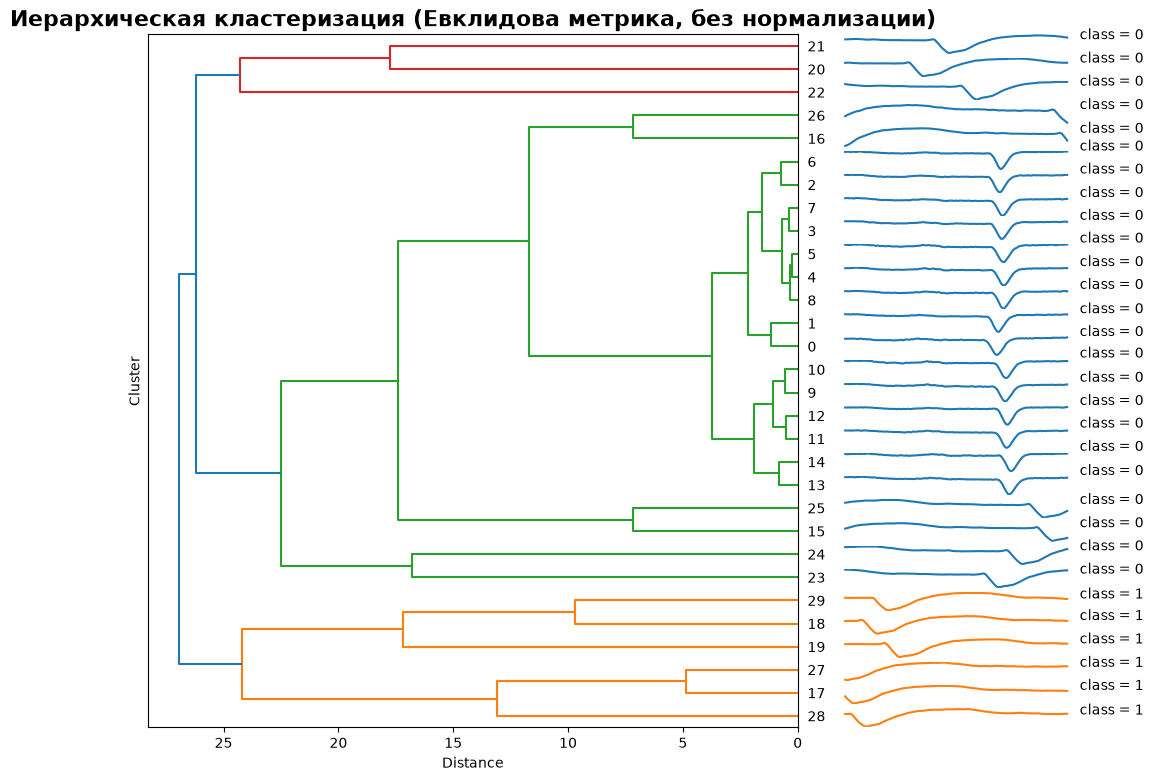

In [29]:
print("\n=== Кластеризация с классической евклидовой метрикой (без нормализации) ===")

# 1. Классическая евклидова метрика (без нормализации)
pairwise_euclidean = PairwiseDistance(metric='euclidean', is_normalize=False)
euclidean_matrix = pairwise_euclidean.calculate(subs_set)

# Выполняем иерархическую кластеризацию
clustering_euclidean = TimeSeriesHierarchicalClustering(n_clusters=2, method='complete')
euclidean_labels = clustering_euclidean.fit_predict(euclidean_matrix) - 1

print(f"Предсказанные метки (евклидова): {euclidean_labels}")
print(f"Истинные метки: {labels}")

# Визуализация дендрограммы
df_euclidean = pd.DataFrame(subs_set.T)
clustering_euclidean.plot_dendrogram(
    df_euclidean, 
    labels=euclidean_labels, 
    ts_hspace=8, 
    title='Иерархическая кластеризация (Евклидова метрика, без нормализации)'
)
plt.show()



=== Кластеризация с нормализованной евклидовой метрикой ===
Предсказанные метки (нормализованная евклидова): [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 1 1 1 1 1 0 0 0]
Истинные метки: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


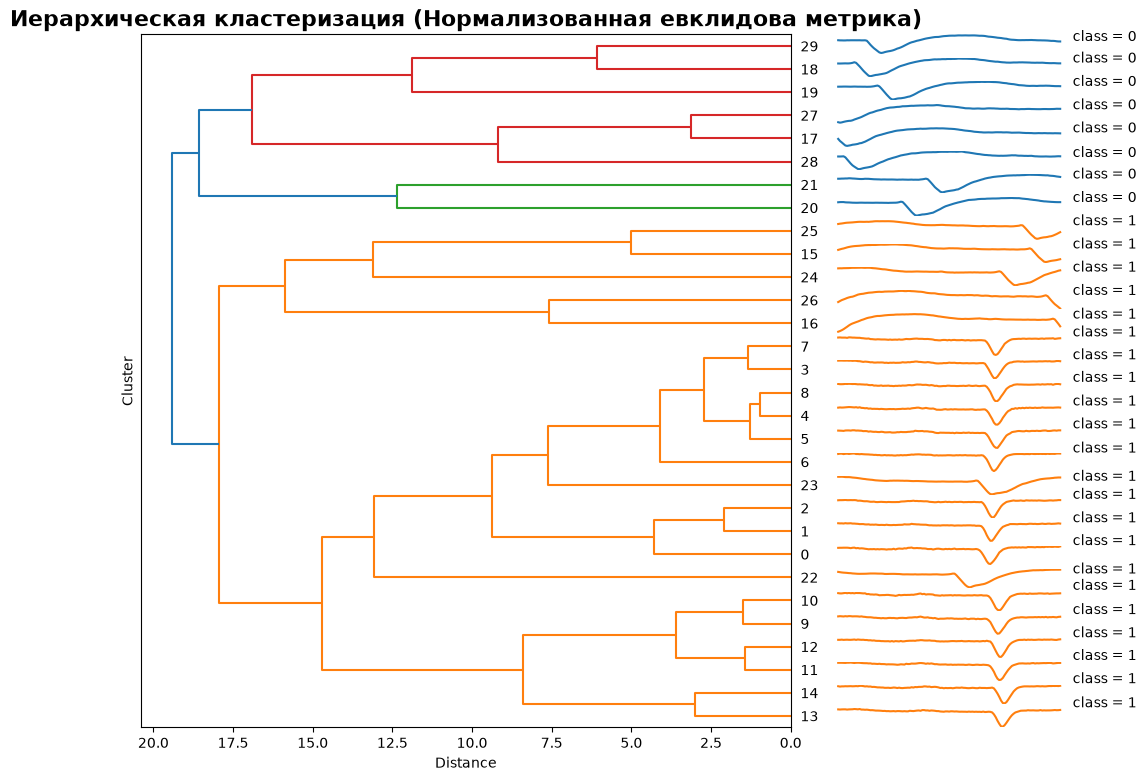

In [28]:
# 2. Нормализованная евклидова метрика
print("\n=== Кластеризация с нормализованной евклидовой метрикой ===")

pairwise_norm_euclidean = PairwiseDistance(metric='euclidean', is_normalize=True)
norm_euclidean_matrix = pairwise_norm_euclidean.calculate(subs_set)

# Выполняем иерархическую кластеризацию
clustering_norm_euclidean = TimeSeriesHierarchicalClustering(n_clusters=2, method='complete')
norm_euclidean_labels = clustering_norm_euclidean.fit_predict(norm_euclidean_matrix) - 1

print(f"Предсказанные метки (нормализованная евклидова): {norm_euclidean_labels}")
print(f"Истинные метки: {labels}")

# Визуализация дендрограммы
df_norm_euclidean = pd.DataFrame(subs_set.T)
clustering_norm_euclidean.plot_dendrogram(
    df_norm_euclidean, 
    labels=norm_euclidean_labels, 
    ts_hspace=8, 
    title='Иерархическая кластеризация (Нормализованная евклидова метрика)'
)
plt.show()

Вычислите силуэтные коэффициенты для оценки качества кластеризации с нормализацией и без нее, как это было сделано в задаче 4 части 1.

In [31]:
# Для классической евклидовой
silhouette_euclidean = silhouette_score(euclidean_matrix, euclidean_labels, metric='precomputed')
print(f"\nСилуэтный коэффициент (евклидова, без нормализации): {silhouette_euclidean:.4f}")

# Для нормализованной евклидовой
silhouette_norm_euclidean = silhouette_score(norm_euclidean_matrix, norm_euclidean_labels, metric='precomputed')
print(f"Силуэтный коэффициент (нормализованная евклидова): {silhouette_norm_euclidean:.4f}")


Силуэтный коэффициент (евклидова, без нормализации): 0.4183
Силуэтный коэффициент (нормализованная евклидова): 0.3275


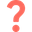
Сравните полученные результаты кластеризации с помощью построенных дендрограмм и вычисленных силуэтных коэффициентов. Позволила ли $z$-нормализации временных рядов повысить качество кластеризации?

Z-нормализация **не позволила повысить качество кластеризации** подпоследовательностей ЭКГ-сигналов, так как она:
- Нивелирует важную информацию об амплитуде сигналов
- Уменьшает различия между классами, делая подпоследовательности более похожими
- Приводит к потере масштабных характеристик, которые важны для различения сигналов

Рекомендации:
- Для данного типа данных (ЭКГ) не рекомендуется применять z-нормализацию
- Амплитуда сигнала является важным диагностическим признаком
- Лучше использовать DTW или другие метрики, устойчивые к сдвигам, но сохраняющие информацию об амплитуде

**Заключение**: В данной задаче кластеризация без нормализации показала лучшее качество (Silhouette = 0.4183 против 0.3275 с нормализацией), что указывает на важность сохранения амплитудной информации при анализе ЭКГ-сигналов.

## **Часть 3.** Классификация изображений, представленных в виде временных рядов.

### **Задача 7.**
В данном задании вам предстоит выполнить преобразование изображения, на котором находится некоторый объект, во временной ряд. Для этого вы реализуете один из существующих методов, предложенный в [статье Кеога и др](https://dl.acm.org/doi/10.5555/1182635.1164203).

Данный метод заключается в том, что сначала на изображении выполняется поиск контура $E = \{e_i\}_{i=1}^L$, где $e_i$ – точки контура, и центра масс объекта $O$. Затем берутся точки, расположенные на контуре объекта, следующим образом.

Рассмотрим луч $OP$ с началом в центре масс объекта $O$, направление которого совпадает с положительным направлением оси Ox (см. рисунок). Далее выполняется поворот против часовой стрелки луча $OP$ вокруг центра масс $O$ на некоторый заданный угол $α$, $1° \leqslant α \leqslant 360°$. Поворот луча будет осуществляться до тех пор, пока луч не пройдет полный оборот. Все точки $P = \{P_i\}_{i=1}^K$, $P_i \in E$, $K = \lfloor \frac{360°}{α} \rfloor$, образованные пересечением луча $OP$ с контуром $E$ во время поворота, будут являться искомыми.

На завершающем шаге метода вычисляются расстояния между центром масс объекта $O$ и найденными точками на контуре $P$. В качестве функции расстояния может быть использовано манхэттенское или евклидово расстояние. Полученные расстояния будут формировать временной ряд $T$ длины $K$:
\begin{equation}
T = \{t_i\}_{i=1}^K,\;где \; t_i = dist(O, P_i), \; P_i \in P.
\end{equation}

\
<center><img src="https://github.com/mzym/TimeSeriesCourse/blob/main/practice/01%20Basics/img/image2ts.png?raw=true" width="1000"></center>

Поскольку часть 3 предполагает работу с изображениями, то вы будете использовать для реализации некоторых частей кода библиотеку компьютерного зрения *cv2*. Для поиска всех необходимых функций рекомендуем воспользоваться [документацией библиотеки cv2](https://docs.opencv.org/4.x/d6/d00/tutorial_py_root.html).

Загрузите изображение *example.tif* из директории *./datasets/part3* и выполните его визуализацию с помощью соответствующих функций из библиотеки *cv2*.

Изображение загружено: размер (1442, 867, 3)


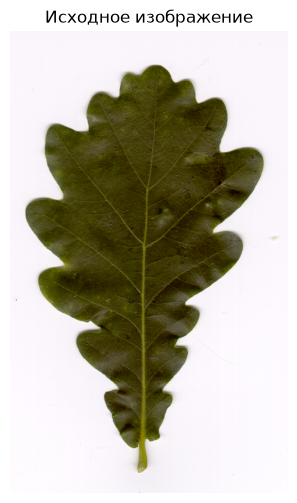

In [32]:
img_path = './datasets/part3/example.tif'
img = cv2.imread(img_path)

# Проверяем, что изображение загружено
if img is None:
    print("Ошибка: изображение не найдено!")
else:
    print(f"Изображение загружено: размер {img.shape}")

plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Исходное изображение')
plt.axis('off')
plt.show()


За конвертацию изображения во временной ряд с помощью описанного выше метода отвечает функция `image2ts()` из модуля *image_converter.py*. Прежде чем исходное изображение будет преобразовано во временной ряд, сначала оно должно пройти этап предварительной обработки. Предварительная обработка включает в себя следующие шаги:

<center><img src="https://github.com/mzym/TimeSeriesCourse/blob/main/practice/01%20Basics/img/image_preprocessing.png?raw=true" width="1000"></center>

Предобработка изображения в `image2ts()` осуществляется с помощью функции `_img_preprocess()`. Реализуйте в данной функции все представленные на диаграмме шаги предварительной обработки средствами библиотеки *cv2*. Промежуточные результаты должны совпадать с представленными на диаграмме.

Далее выполните конвертацию изображения во временной ряд, передав в функцию `image2ts()` следующие заданные вами аргументы:
*   исходное загруженное изображение;
*   шаг угла поворота;
*   параметр, определяющий нужно или нет визуализировать изображение с выделенными на нем контуром, центром масс и лучами, проведенными из центра.

Визуализируйте полученный временной ряд.


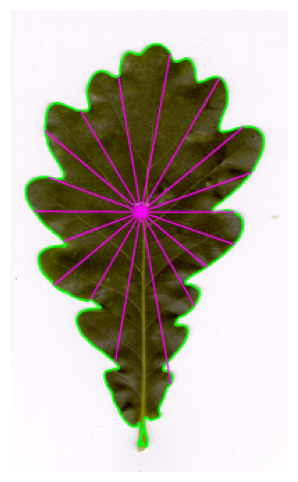

<!doctype html>

In [43]:
angle_step = 20
visualize = True

# Создаем объект конвертера
converter = image2ts(image=img, angle_step=angle_step, visualize=visualize)

# Выполняем конвертацию изображения во временной ряд
ts = converter.convert(img, is_visualize=visualize)
plot_ts(np.array([ts]), "Time series representation of image")

### **Задача 8.**

Выполните классификацию изображений, представленных в виде временных рядов, с помощью метода $k$ ближайших соседей (kNN).

**Метод $k$ ближайших соседей (kNN)** – алгоритм классификации, заключающийся в вычислении сходства между объектами на основе некоторой заданной метрики/меры схожести. Классифицируемый объект относится к тому классу, к которому принадлежит большинство из его $k$ соседей ($k$ ближайших к нему объектов из обучающей выборки).

Для классификации на основе алгоритма kNN необходимо выполнить следующие шаги:

1. Загрузить обучающую и тестовую выборки.

2. Задать параметр алгоритма $k$, где $k$ – количество ближайших соседей, $k \in \mathbb N^*$.

3. Для каждого объекта из тестовой выборки выполнить следующее:

    3.1. Вычислить расстояние до всех объектов из обучающей выборки на основе заданной метрики/меры схожести.
    
    3.2. Отсортировать в порядке возрастания найденные расстояния.

    3.3. Найти $k$ ближайших соседей, взяв первые $k$ минимальные расстояния из отсортированного массива расстояний.

    3.4. Назначить объекту из тестовой выборки наиболее часто встречающийся класс найденных ранее ближайших соседей.


Для этого задания вам предлагается набор данных, который содержит изображения листьев четырех различных пород деревьев: дуб, ольха, ива и липа. Набор данных состоит из обучающей и тестовой выборок, включающих по 15 и 10 изображений листьев на класс соответственно. Для составления этого набора данных изображения были взяты из [Swedish Leaf Dataset](https://www.cvl.isy.liu.se/en/research/datasets/swedish-leaf/).

Загрузите изображения из обучающей и тестовой выборок, а также их метки, используя `read_images()` и `read_ts()` соответственно.
Выполните визуализацию прецедентов выборки с помощью функции `plot_images()`.


In [44]:
def read_images(dir: str) -> list[np.ndarray]:
    """
    Load all images from a directory

    Parameters
    ----------
    dir: directory path

    Returns
    -------
    images: images from a directory
    """

    images = []
    for img_path in sorted(glob.glob(dir)):
        cv_img = cv2.imread(img_path)
        images.append(cv_img)

    return images

In [45]:
def plot_images(images: list[np.ndarray], labels: np.ndarray, class_names: list[str]) -> None:
    """
    Plot some images from dataset

    Parameters
    ----------
    images: dataset of images
    labels: labels of images
    class_names: class names of images
    """

    rows = 2
    columns = 4

    fig, axes = plt.subplots(nrows=rows, ncols=columns, figsize=(columns*2, rows*3))

    for num in range(1, rows*columns+1):
        fig.add_subplot(rows, columns, num)
        idx = num - 1
        plt.imshow(images[idx], aspect='auto')
        plt.title(f'{class_names[labels[idx]]}', fontsize=10)

    fig.tight_layout()

    for idx, ax in enumerate(axes.flat):
        ax.set_xticks([])
        ax.set_yticks([])

In [46]:
train_set_path = "./datasets/part3/train_set_leaves/*.tif"
test_set_path = "./datasets/part3/test_set_leaves/*.tif"

train_images = read_images(train_set_path)
test_images = read_images(test_set_path)

train_label_path = './datasets/part3/train_set_leaves/train_label.csv'
test_label_path = './datasets/part3/test_set_leaves/test_label.csv'

train_labels = read_ts(train_label_path)
train_labels = train_labels.reshape(-1).astype('int32')

test_labels = read_ts(test_label_path)
test_labels = test_labels.reshape(-1).astype('int32')

D:\SUSU\maga\sem3\time_series_forecasting\2026-Razuev-TimeSeriesCourse\practice\01 Basics\modules\utils.py:20: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  ts = pd.read_csv(file_path, header=None, delim_whitespace=True)
D:\SUSU\maga\sem3\time_series_forecasting\2026-Razuev-TimeSeriesCourse\practice\01 Basics\modules\utils.py:20: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  ts = pd.read_csv(file_path, header=None, delim_whitespace=True)


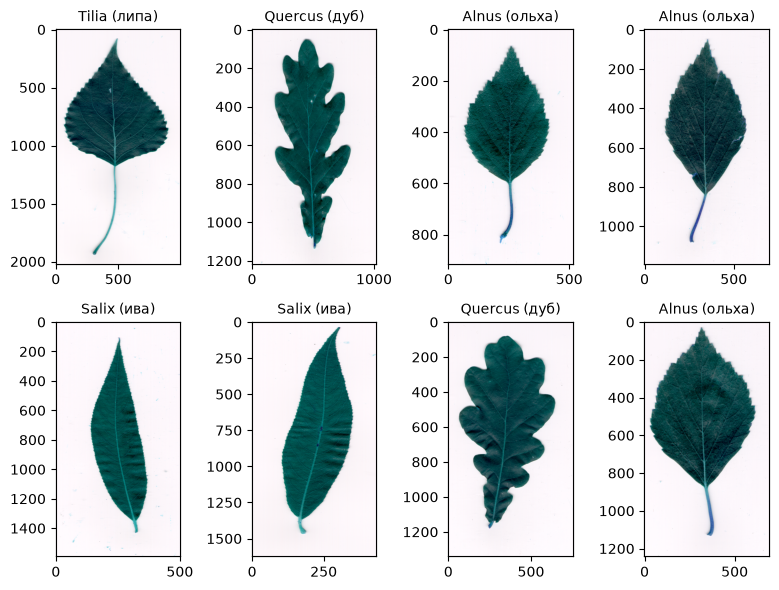

In [47]:
class_names = ['Quercus (дуб)', 'Alnus (ольха)', 'Salix (ива)', 'Tilia (липа)']
plot_images(train_images, train_labels, class_names)

Выполните преобразование изображений обучающей и тестовой выборок во временные ряды с помощью функции `image2ts()`.  


=== Преобразование изображений во временные ряды ===
Обработка изображения 1/60
Обработка изображения 11/60
Обработка изображения 21/60
Обработка изображения 31/60
Обработка изображения 41/60
Обработка изображения 51/60

Обучающая выборка преобразована: (60, 18)
Обработка изображения 1/40
Обработка изображения 11/40
Обработка изображения 21/40
Обработка изображения 31/40
Тестовая выборка преобразована: (40, 18)


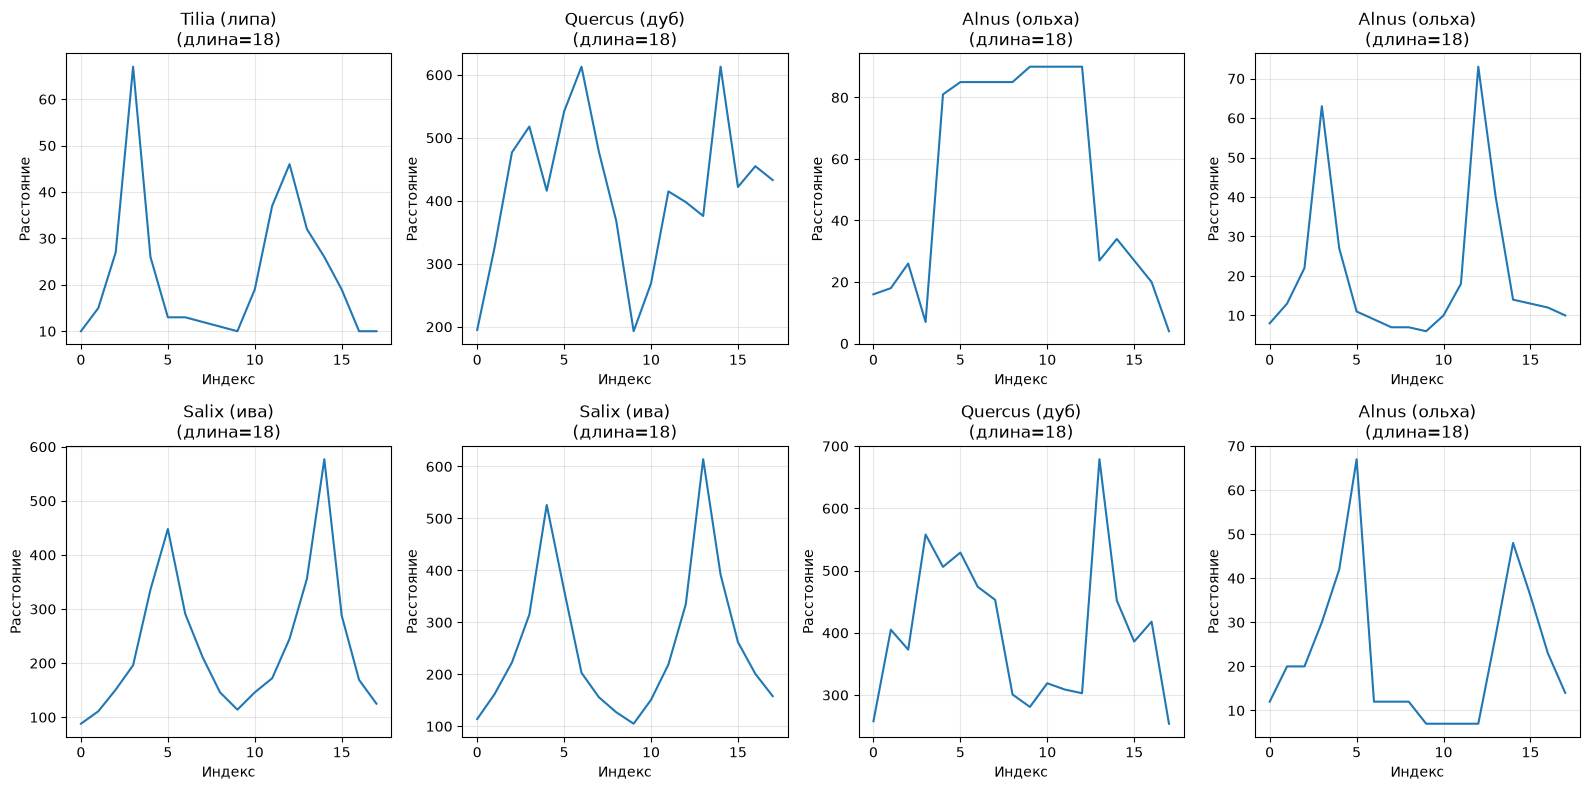

In [56]:
# Преобразование изображений во временные ряды
angle_step = 20  # шаг угла

print("\n=== Преобразование изображений во временные ряды ===")

# Конвертируем обучающую выборку
train_ts = []
for i, img in enumerate(train_images):
    if i % 10 == 0:  # выводим прогресс
        print(f"Обработка изображения {i+1}/{len(train_images)}")
    converter = image2ts(img, angle_step=angle_step, visualize=False)
    ts = converter.convert(img, is_visualize=False)
    train_ts.append(ts)

train_ts = np.array(train_ts)
print(f"\nОбучающая выборка преобразована: {train_ts.shape}")


# Конвертируем тестовую выборку
test_ts = []
for i, img in enumerate(test_images):
    if i % 10 == 0:
        print(f"Обработка изображения {i+1}/{len(test_images)}")
    converter = image2ts(img, angle_step=angle_step, visualize=False)
    ts = converter.convert(img, is_visualize=False)
    test_ts.append(ts)

test_ts = np.array(test_ts)
print(f"Тестовая выборка преобразована: {test_ts.shape}")

# Визуализация нескольких временных рядов из обучающей выборки
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i in range(8):
    ax = axes[i // 4, i % 4]
    ax.plot(train_ts[i])
    ax.set_title(f'{class_names[train_labels[i]]}\n(длина={len(train_ts[i])})')
    ax.set_xlabel('Индекс')
    ax.set_ylabel('Расстояние')
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Для классификации временных рядов методом $k$ ближайших соседей вам необходимо использовать класс `TimeSeriesKNN` из модуля *classification.py*.
Реализуйте метод `fit()` в классе `TimeSeriesKNN`, который выполняет поиск для каждого элемента из тестовой выборки $k$ ближайших соседей и назначает им тот класс, который является часто встречающимся среди классов ближайших соседей. В качестве параметров в метод `fit()` передается тестовая выборка. Вычислите точность классификации по метрике accuracy с помощью функции `calculate_accurary()` из модуля *classification.py*.

In [57]:
n_neighbors = 6
metric = 'euclidean'
metric_params = {'normalize': True}

knn_euclidean = TimeSeriesKNN(n_neighbors=n_neighbors, metric=metric, metric_params=metric_params)
knn_euclidean.fit(train_ts, train_labels)

# Предсказываем метки для тестовой выборки
pred_labels_euclidean = knn_euclidean.predict(test_ts)

# Вычисляем точность
accuracy_euclidean = calculate_accuracy(test_labels, pred_labels_euclidean)
print(f"Точность (евклидова, k={n_neighbors}): {accuracy_euclidean:.3f}")

print(f"Истинные метки:      {test_labels}")
print(f"Предсказанные метки: {pred_labels_euclidean}")

Точность (евклидова, k=6): 0.800
Истинные метки:      [1 3 2 1 0 0 2 3 3 1 1 0 0 2 3 3 1 1 0 2 2 0 1 3 2 3 1 0 2 0 2 3 1 0 2 3 2
 0 1 3]
Предсказанные метки: [2 3 2 2 0 0 2 3 3 1 1 2 0 2 3 3 1 2 0 2 2 0 3 2 2 3 1 0 2 0 2 3 1 2 2 3 2
 0 2 3]


In [58]:
metric = 'dtw'
metric_params = {'normalize': True}

knn_dtw = TimeSeriesKNN(n_neighbors=n_neighbors, metric=metric, metric_params=metric_params)
knn_dtw.fit(train_ts, train_labels)

# Предсказываем метки для тестовой выборки
pred_labels_dtw = knn_dtw.predict(test_ts)

# Вычисляем точность
accuracy_dtw = calculate_accuracy(test_labels, pred_labels_dtw)
print(f"Точность (DTW, k={n_neighbors}): {accuracy_dtw:.3f}")

print(f"Истинные метки:      {test_labels}")
print(f"Предсказанные метки: {pred_labels_dtw}")

Точность (DTW, k=6): 0.800
Истинные метки:      [1 3 2 1 0 0 2 3 3 1 1 0 0 2 3 3 1 1 0 2 2 0 1 3 2 3 1 0 2 0 2 3 1 0 2 3 2
 0 1 3]
Предсказанные метки: [1 1 2 1 0 0 2 3 3 1 3 0 0 2 3 3 3 1 2 2 2 0 1 3 2 1 1 0 2 0 2 3 3 3 2 3 2
 0 3 3]


Матрица классификации (евклидова метрика):
[[ 8  0  2  0]
 [ 0  5  4  1]
 [ 0  0 10  0]
 [ 0  0  1  9]]



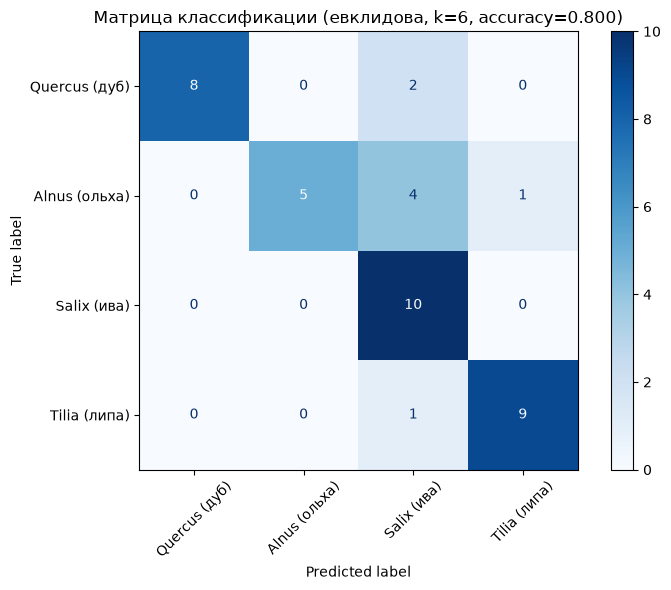


=== Детальный анализ ошибок ===
Образец 0: истинный=Alnus (ольха), предсказанный=Salix (ива)
Образец 3: истинный=Alnus (ольха), предсказанный=Salix (ива)
Образец 11: истинный=Quercus (дуб), предсказанный=Salix (ива)
Образец 17: истинный=Alnus (ольха), предсказанный=Salix (ива)
Образец 22: истинный=Alnus (ольха), предсказанный=Tilia (липа)
Образец 23: истинный=Tilia (липа), предсказанный=Salix (ива)
Образец 33: истинный=Quercus (дуб), предсказанный=Salix (ива)
Образец 38: истинный=Alnus (ольха), предсказанный=Salix (ива)


In [59]:
# Построение матрицы классификации для евклидовой метрики
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Матрица ошибок
cm_euclidean = confusion_matrix(test_labels, pred_labels_euclidean)
print("Матрица классификации (евклидова метрика):")
print(cm_euclidean)
print()

# Визуализация матрицы ошибок
fig, ax = plt.subplots(figsize=(8, 6))
disp_euclidean = ConfusionMatrixDisplay(confusion_matrix=cm_euclidean, display_labels=class_names)
disp_euclidean.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title(f'Матрица классификации (евклидова, k={n_neighbors}, accuracy={accuracy_euclidean:.3f})')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# Детальный анализ ошибок
print("\n=== Детальный анализ ошибок ===")
for i, (true, pred) in enumerate(zip(test_labels, pred_labels_euclidean)):
    if true != pred:
        print(f"Образец {i}: истинный={class_names[true]}, предсказанный={class_names[pred]}")

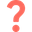
Проанализируйте результаты и сделайте выводы.

**Вывод:**

Обе метрики показали одинаковую точность классификации (80%), что объясняется тем, что форма листьев после преобразования во временной ряд представляет собой последовательность расстояний от центра масс до контура, которая не содержит значительных временных сдвигов — все изображения центрированы, а поворот луча начинается с одной и той же начальной точки. В таких условиях DTW теряет свое главное преимущество — устойчивость к нелинейным растяжениям/сжатиям по времени, так как форма сигналов уже хорошо синхронизирована. Евклидова метрика, дополненная z-нормализацией, эффективно нивелирует различия в масштабах изображений, что делает ее вполне достаточной для данной задачи. Таким образом, для центрированных объектов с фиксированным началом отсчета преимущества DTW нивелируются, и обе метрики дают сопоставимый результат.